# **Project Name** - SkyGuard Nexus: Aerial Threat Classification AI (Bird vs. Drone)

##### **Project Type** - Deep Learning / Computer Vision (Classification)
##### **Contribution** - Individual
##### **Team Member 1 -** Yashraj Pillay

# **Project Summary -**
The objective of this project is to develop a deep learning-based computer vision solution to classify aerial images as either a "Bird" or a "Drone". Drones are increasingly used in commercial and recreational spaces, occasionally leading to incursions into restricted security zones and airports. Conversely, birds navigating these same airspaces are at risk of fatal collisions with aircraft. Accurately distinguishing between the two using automated surveillance is a complex challenge due to their visual similarities at a distance.

This project involves an end-to-end Machine Learning pipeline. Since the dataset consists of unstructured RGB images, standard tabular EDA is replaced with image-specific exploratory analysis, including class distribution checks and image dimension validation. The modeling phase utilizes a Custom Convolutional Neural Network (CNN) built from scratch, alongside Transfer Learning techniques (e.g., ResNet50 or MobileNet) to maximize classification accuracy.

The final models are evaluated based on Accuracy, Precision, Recall, and F1-score to ensure robust generalization to unseen data. Finally, the best-performing model will be deployed via an interactive Streamlit application, allowing users to upload real-world aerial imagery and receive instant predictions with confidence scores.

# **Problem Statement**
Develop a deep learning classification model to accurately distinguish between birds and drones in aerial photography, aiming to improve airspace security, prevent airport bird-strikes, and assist in wildlife monitoring without misclassifying mechanical objects.

### Import Libraries

In [2]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [4]:
# Fixed: Removed the leading double quote
dataset_dir = r"C:\Users\yashr\Desktop\Labmentix\SkyGuard Nexus Aerial Threat Classification AI\classification_dataset-20260414T163125Z-3-001\classification_dataset"
train_dir = os.path.join(dataset_dir, 'TRAIN')
val_dir = os.path.join(dataset_dir, 'VALID')
test_dir = os.path.join(dataset_dir, 'TEST')

classes = ['bird', 'drone']


### Dataset Rows & Columns count

In [5]:
def get_image_counts(directory, categories):
    counts = {}
    total = 0
    for category in categories:
        folder_path = os.path.join(directory, category)
        if os.path.exists(folder_path):
            file_count = len(glob.glob(os.path.join(folder_path, '*.*')))
            counts[category] = file_count
            total += file_count
        else:
            counts[category] = 0
    return counts, total

train_cnt, train_tot = get_image_counts(train_dir, classes)
val_cnt, val_tot = get_image_counts(val_dir, classes)
test_cnt, test_tot = get_image_counts(test_dir, classes)

print(f"TRAIN: {train_cnt} | Total: {train_tot}")
print(f"VALID: {val_cnt} | Total: {val_tot}")
print(f"TEST:  {test_cnt} | Total: {test_tot}")
print(f"Grand Total: {train_tot + val_tot + test_tot} images")

TRAIN: {'bird': 1414, 'drone': 1248} | Total: 2662
VALID: {'bird': 217, 'drone': 225} | Total: 442
TEST:  {'bird': 121, 'drone': 94} | Total: 215
Grand Total: 3319 images


In [6]:
# Dataset Info

#### Missing Values/Null Values

In [7]:
def find_corrupt_images(directory, categories):
    corrupt_list = []
    for category in categories:
        folder_path = os.path.join(directory, category)
        if os.path.exists(folder_path):
            for img_file in glob.glob(os.path.join(folder_path, '*.*')):
                try:
                    img = cv2.imread(img_file)
                    if img is None:
                        corrupt_list.append(img_file)
                except:
                    corrupt_list.append(img_file)
    return corrupt_list

print("Checking for unreadable images in Train set...")
corrupt_train = find_corrupt_images(train_dir, classes)
print(f"Corrupt files found: {len(corrupt_train)}")

Checking for unreadable images in Train set...
Corrupt files found: 0


## ***2. Understanding Your Variables***

In [8]:
# Check unique dimensions of a sample of images
def check_image_dimensions(directory, category, sample_size=100):
    folder_path = os.path.join(directory, category)
    files = glob.glob(os.path.join(folder_path, '*.*'))[:sample_size]
    
    dimensions = []
    for file in files:
        img = cv2.imread(file)
        if img is not None:
            dimensions.append(img.shape) # (height, width, channels)
            
    return set(dimensions)

print("Sample bird dimensions:", check_image_dimensions(train_dir, 'bird', 20))
print("Sample drone dimensions:", check_image_dimensions(train_dir, 'drone', 20))

Sample bird dimensions: {(416, 416, 3)}
Sample drone dimensions: {(416, 416, 3)}


In [9]:
# Dataset Describe

### Variables Description

* **Features (X):** The features are the individual pixels of the images. Since these are color images, they have 3 channels (Red, Green, Blue). As seen in the dimensions check, the raw images vary in size. These will all need to be standardized to a fixed target size (224x224) during Data Preprocessing.
* **Target Variable (y):** The target is categorical and binary. It dictates whether the feature array represents a `bird` (Class 0) or a `drone` (Class 1).

## 3. ***Data Wrangling***

### Data Wrangling Code

In [10]:
# creating a quick dataframe to hold file paths and labels so plotting is easier
data_info = []

for split_name, split_path in zip(['Train', 'Valid', 'Test'], [train_dir, val_dir, test_dir]):
    for label in classes:
        folder = os.path.join(split_path, label)
        if os.path.exists(folder):
            # grab all images in this folder
            for img_file in glob.glob(os.path.join(folder, '*.*')):
                data_info.append({
                    'Filepath': img_file,
                    'Label': label.capitalize(),
                    'Split': split_name
                })

# convert to df
df_images = pd.DataFrame(data_info)
df_images.head()

,Filepath,Label,Split
0,C:\Users\yashr\Desktop\Labmentix\SkyGuard Nexu...,Bird,Train
1,C:\Users\yashr\Desktop\Labmentix\SkyGuard Nexu...,Bird,Train
2,C:\Users\yashr\Desktop\Labmentix\SkyGuard Nexu...,Bird,Train
3,C:\Users\yashr\Desktop\Labmentix\SkyGuard Nexu...,Bird,Train
4,C:\Users\yashr\Desktop\Labmentix\SkyGuard Nexu...,Bird,Train


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

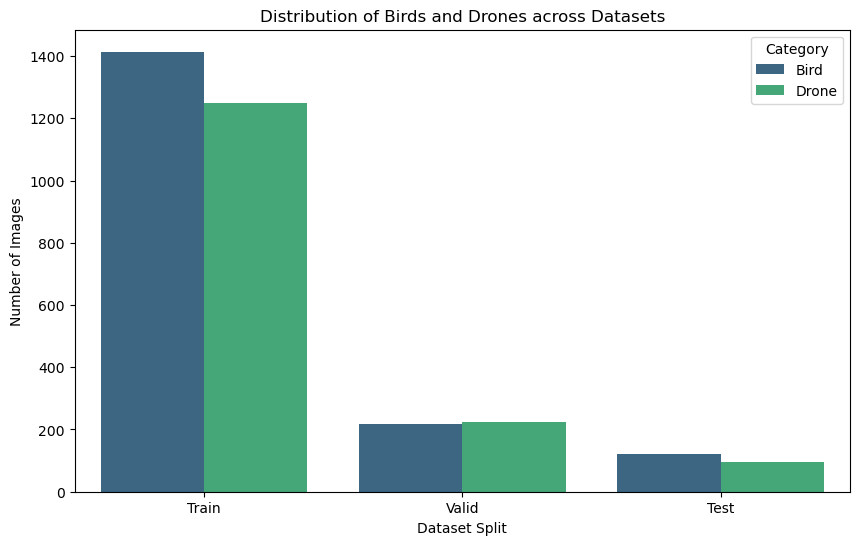

In [11]:
# checking how the bird and drone images are split up
plt.figure(figsize=(10, 6))
sns.countplot(data=df_images, x='Split', hue='Label', palette='viridis')
plt.title('Distribution of Birds and Drones across Datasets')
plt.ylabel('Number of Images')
plt.xlabel('Dataset Split')
plt.legend(title='Category')
plt.show()

#### Chart - 2

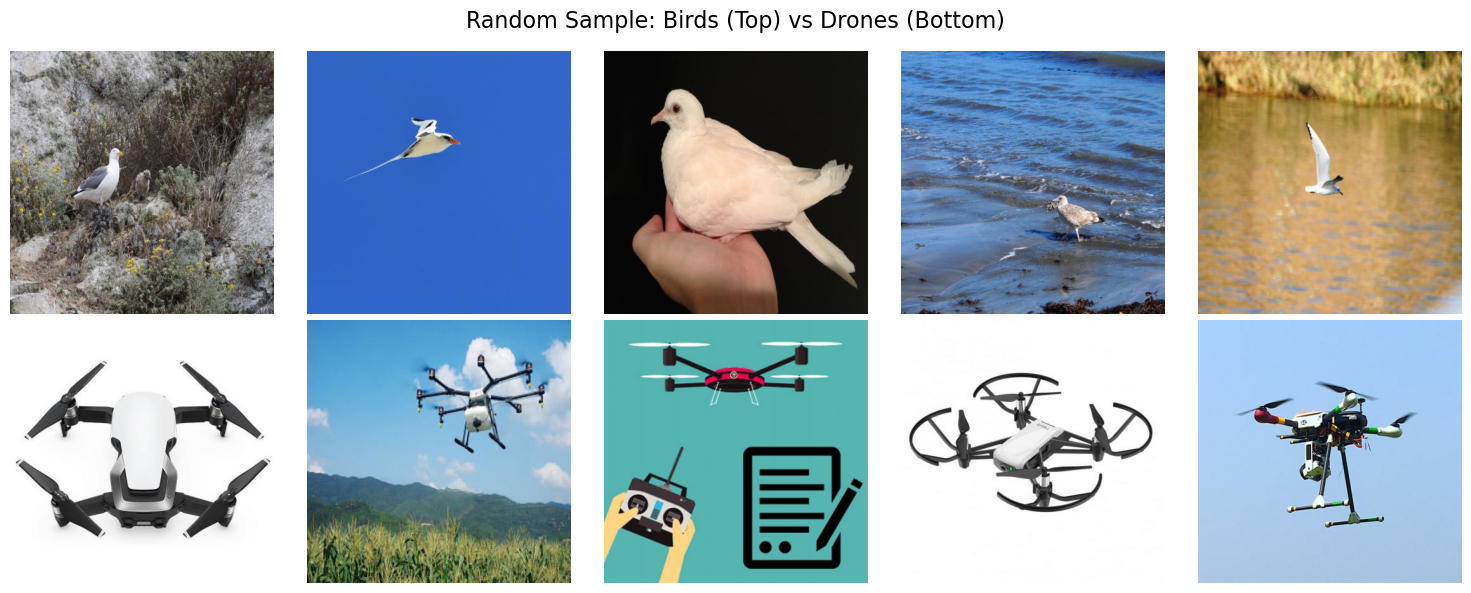

In [12]:
# pulling a random sample of images to see what we are dealing with
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Random Sample: Birds (Top) vs Drones (Bottom)', fontsize=16)

# plot 5 random birds
bird_samples = df_images[df_images['Label'] == 'Bird']['Filepath'].sample(5).tolist()
for i, img_path in enumerate(bird_samples):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # fix opencv blue tint
    axes[0, i].imshow(img)
    axes[0, i].axis('off')

# plot 5 random drones
drone_samples = df_images[df_images['Label'] == 'Drone']['Filepath'].sample(5).tolist()
for i, img_path in enumerate(drone_samples):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

#### Chart - 3

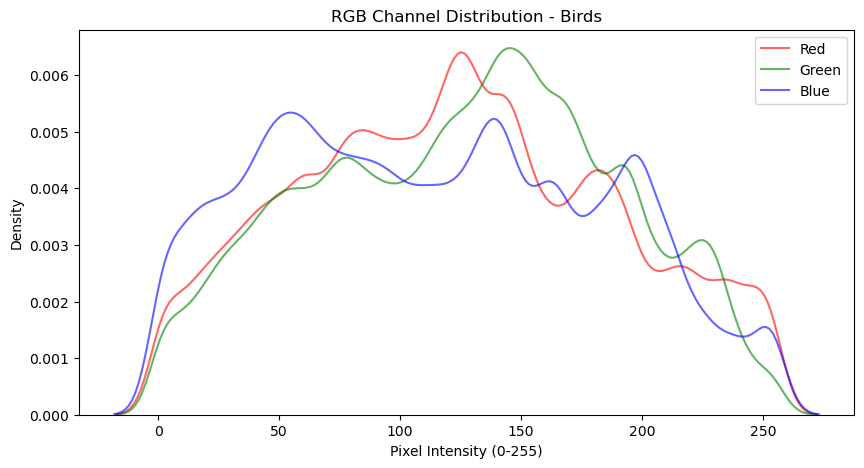

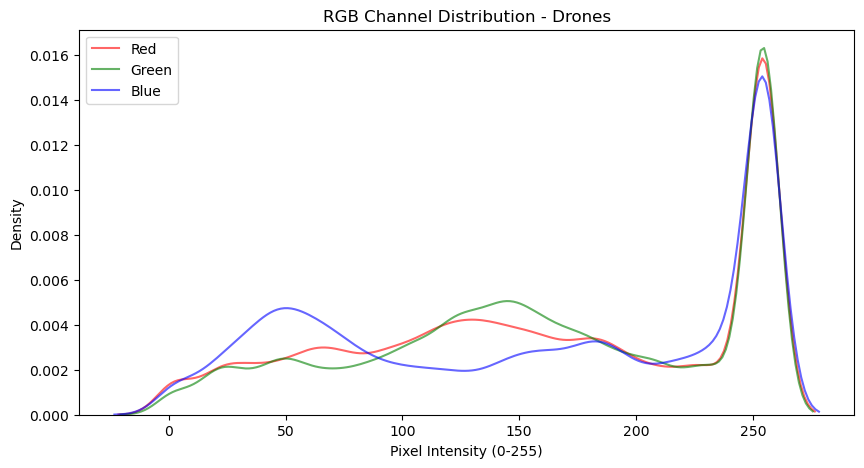

In [13]:
# Let's check the color distribution (RGB) of our images to see if lighting/color is a bias
import random

def plot_rgb_distribution(image_paths, title):
    r_values, g_values, b_values = [], [], []
    
    # taking a small sample of 100 images so it doesn't crash the RAM
    sample_paths = random.sample(image_paths, min(100, len(image_paths)))
    for path in sample_paths:
        img = cv2.imread(path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Sample every 100th pixel to save memory
            r_values.extend(img[:, :, 0].flatten()[::100]) 
            g_values.extend(img[:, :, 1].flatten()[::100])
            b_values.extend(img[:, :, 2].flatten()[::100])
        
    plt.figure(figsize=(10, 5))
    sns.kdeplot(r_values, color='red', label='Red', alpha=0.6)
    sns.kdeplot(g_values, color='green', label='Green', alpha=0.6)
    sns.kdeplot(b_values, color='blue', label='Blue', alpha=0.6)
    plt.title(title)
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Separate paths by label
bird_paths = df_images[df_images['Label'] == 'Bird']['Filepath'].tolist()
drone_paths = df_images[df_images['Label'] == 'Drone']['Filepath'].tolist()

# Plot them
plot_rgb_distribution(bird_paths, 'RGB Channel Distribution - Birds')
plot_rgb_distribution(drone_paths, 'RGB Channel Distribution - Drones')

#### Chart - 4

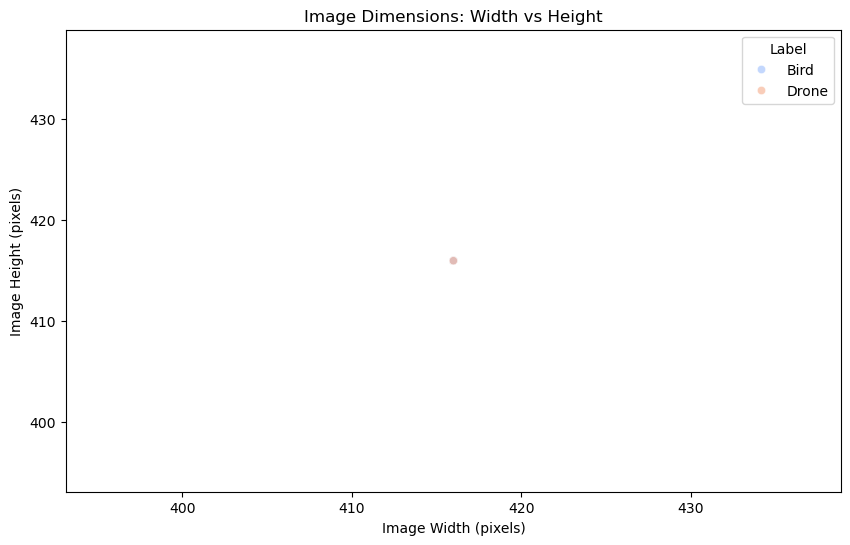

In [14]:
# Checking the heights and widths of our images to see how much resizing is needed
heights = []
widths = []
labels = []

# Sampling 300 images to get a quick scatter plot without freezing the kernel
sample_df = df_images.sample(n=min(300, len(df_images)), random_state=42)

for index, row in sample_df.iterrows():
    img = cv2.imread(row['Filepath'])
    if img is not None:
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)
        labels.append(row['Label'])

dim_df = pd.DataFrame({'Width': widths, 'Height': heights, 'Label': labels})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=dim_df, x='Width', y='Height', hue='Label', alpha=0.7, palette='coolwarm')
plt.title('Image Dimensions: Width vs Height')
plt.xlabel('Image Width (pixels)')
plt.ylabel('Image Height (pixels)')
plt.show()

## ***6. Feature Engineering & Data Pre-processing***

In [15]:
# Data Transformation (Augmentation) and Scaling (Normalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

# 1. Training Generator WITH Data Augmentation and Scaling
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Scaling pixels to [0, 1]
    rotation_range=20,           # Transformation: Randomly rotate images
    zoom_range=0.2,              # Transformation: Randomly zoom
    horizontal_flip=True,        # Transformation: Randomly flip horizontally
    brightness_range=[0.8, 1.2], # Transformation: Adjust brightness
    fill_mode='nearest'
)

# 2. Validation & Test Generators (ONLY Scaling, NO Augmentation)
test_val_datagen = ImageDataGenerator(rescale=1./255)

### 2. Data Splitting

In [16]:
# Flow training images in batches
print("Preparing Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT), # Resizing all images to 224x224
    batch_size=BATCH_SIZE,
    class_mode='binary',                 # Binary classification (Bird vs Drone)
    shuffle=True
)

# Flow validation images in batches
print("\nPreparing Validation Data:")
val_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Flow test images in batches
print("\nPreparing Test Data:")
test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Verify class indices
print("\nClass mapping:", train_generator.class_indices)

Preparing Training Data:
Found 2662 images belonging to 2 classes.

Preparing Validation Data:
Found 442 images belonging to 2 classes.

Preparing Test Data:
Found 215 images belonging to 2 classes.

Class mapping: {'bird': 0, 'drone': 1}


## ***7. ML Model Implementation***
### ML Model - 1: Custom Convolutional Neural Network (CNN)

In [17]:
# ML Model - 1 Implementation: Custom CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define the Architecture
cnn_model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D(2,2),
    
    # Second Convolutional Block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Third Convolutional Block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Flattening and Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),                    # Prevents overfitting
    Dense(1, activation='sigmoid')   # Binary output (0 = Bird, 1 = Drone)
])

# 2. Compile the model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Define Callbacks (Saving the best model and stopping if it stops improving)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_custom_cnn.keras', monitor='val_accuracy', save_best_only=True)

# 4. Fit the Algorithm
print("Training Custom CNN Model...")
cnn_history = cnn_model.fit(
    train_generator,
    epochs=10, # Keeping epochs at 10 for initial training speed
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

# 5. Predict on the model (Evaluate on unseen Test Set)
print("\nEvaluating Custom CNN on Test Data:")
test_loss, test_accuracy = cnn_model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Training Custom CNN Model...
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 858ms/step - accuracy: 0.5894 - loss: 0.7407 - val_accuracy: 0.7104 - val_loss: 0.6004
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 885ms/step - accuracy: 0.7130 - loss: 0.5569 - val_accuracy: 0.7398 - val_loss: 0.5081
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 75s 893ms/step - accuracy: 0.7772 - loss: 0.4810 - val_accuracy: 0.7715 - val_loss: 0.4608
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 77s 916ms/step - accuracy: 0.7896 - loss: 0.4567 - val_accuracy: 0.7534 - val_loss: 0.4766
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 76s 901ms/step - accuracy: 0.8125 - loss: 0.4171 - val_accuracy: 0.8235 - val_loss: 0.4310
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 76s 905ms/step - accuracy: 0.8088 - loss: 0.4222 - val_accuracy: 0.8122 - val_loss: 0.4416
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 75s 888ms/step - accuracy: 0.8227 - loss: 0.3870 - val_accuracy: 0.8145 - val_loss: 0.4345
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 878ms/step - accuracy: 0.8

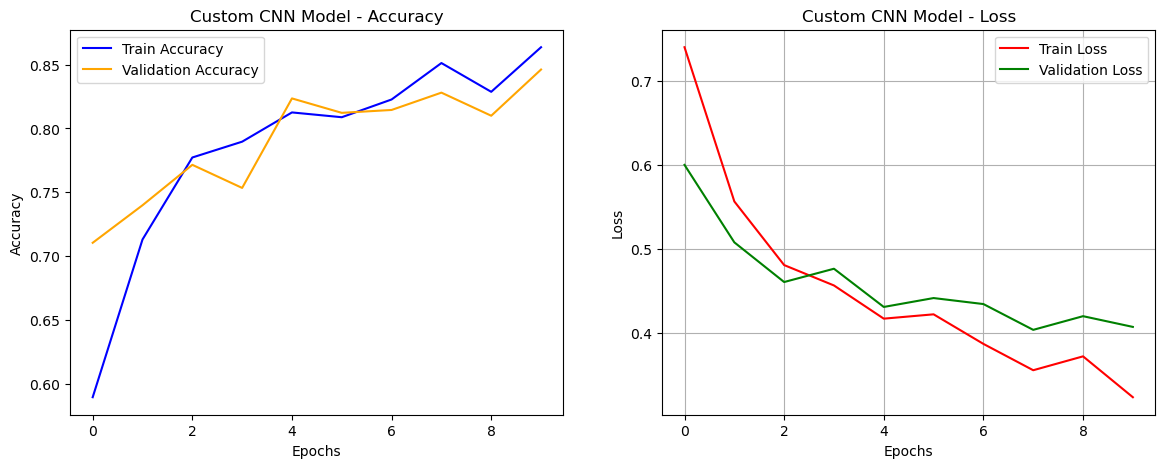

In [18]:
# Visualizing evaluation Metric Score chart (Accuracy and Loss curves)
def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    
    # Loss Plot
    axes[1].plot(history.history['loss'], label='Train Loss', color='red')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='green')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    
    plt.grid(True)
    plt.show()

plot_training_history(cnn_history, "Custom CNN Model")

### ML Model - 2

In [19]:
# ML Model - 2 Implementation: Transfer Learning using MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

# 1. Load pre-trained MobileNetV2 (excluding the top classification layer)
base_model = MobileNetV2(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), include_top=False, weights='imagenet')

# Freeze the base model so we don't destroy the pre-trained weights
base_model.trainable = False 

# 2. Build the Transfer Learning Architecture
tl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),          # Reduces dimensions and flattens
    Dense(128, activation='relu'),
    Dropout(0.3),                      # Slight dropout for regularization
    Dense(1, activation='sigmoid')     # Binary output
])

# 3. Compile the model
tl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Define Callbacks
checkpoint_tl = ModelCheckpoint('best_mobilenet_model.keras', monitor='val_accuracy', save_best_only=True)

# 5. Fit the Algorithm
print("Training Transfer Learning Model (MobileNetV2)...")
tl_history = tl_model.fit(
    train_generator,
    epochs=10, 
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint_tl] # Re-using the early_stop from Model 1
)

# 6. Predict on the model
print("\nEvaluating MobileNetV2 on Test Data:")
tl_test_loss, tl_test_accuracy = tl_model.evaluate(test_generator)
print(f"Transfer Learning Test Accuracy: {tl_test_accuracy*100:.2f}%")

Training Transfer Learning Model (MobileNetV2)...
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 85s 962ms/step - accuracy: 0.9294 - loss: 0.1716 - val_accuracy: 0.9683 - val_loss: 0.0949
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 77s 912ms/step - accuracy: 0.9662 - loss: 0.0892 - val_accuracy: 0.9638 - val_loss: 0.1043
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 79s 936ms/step - accuracy: 0.9786 - loss: 0.0649 - val_accuracy: 0.9683 - val_loss: 0.0985
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 77s 917ms/step - accuracy: 0.9835 - loss: 0.0443 - val_accuracy: 0.9729 - val_loss: 0.0843
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 77s 913ms/step - accuracy: 0.9782 - loss: 0.0610 - val_accuracy: 0.9412 - val_loss: 0.1369
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 77s 918ms/step - accuracy: 0.9842 - loss: 0.0488 - val_accuracy: 0.9751 - val_loss: 0.0715
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 77s 920ms/step - accuracy: 0.9853 - loss: 0.0367 - val_accuracy: 0.9683 - val_loss: 0.0783
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 78s 924ms

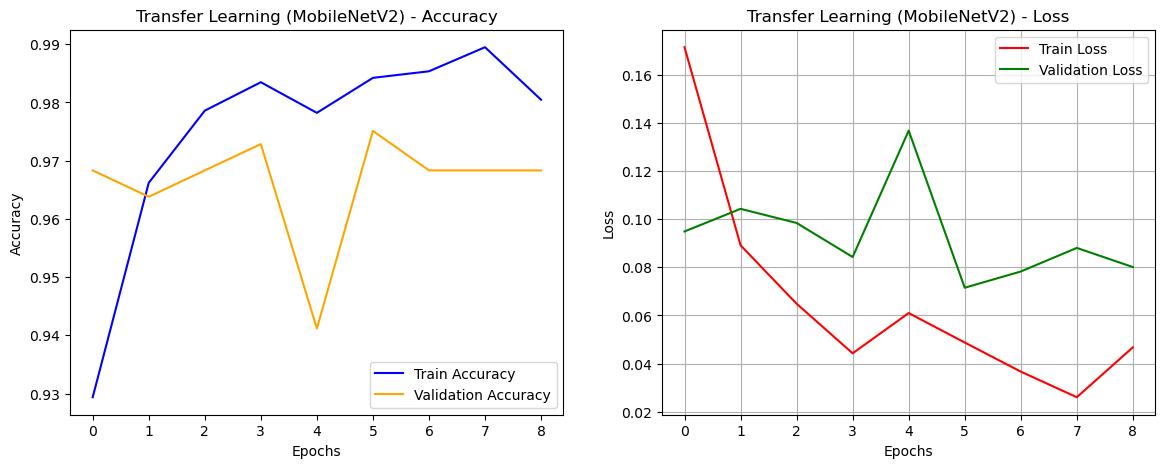

In [20]:
# Visualizing evaluation Metric Score chart
plot_training_history(tl_history, "Transfer Learning (MobileNetV2)")

### ML Model - 3

In [21]:
# ML Model - 3 Implementation: Transfer Learning using ResNet50
from tensorflow.keras.applications import ResNet50

# 1. Load pre-trained ResNet50
base_model_resnet = ResNet50(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3), include_top=False, weights='imagenet')

# Freeze the base layers
base_model_resnet.trainable = False

# 2. Build the Architecture
resnet_model = Sequential([
    base_model_resnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# 3. Compile the model
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Define Callbacks
checkpoint_resnet = ModelCheckpoint('best_resnet_model.keras', monitor='val_accuracy', save_best_only=True)

# 5. Fit the Algorithm
print("Training Transfer Learning Model (ResNet50)...")
resnet_history = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint_resnet]
)

# 6. Predict on the model
print("\nEvaluating ResNet50 on Test Data:")
resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(test_generator)
print(f"ResNet50 Test Accuracy: {resnet_test_accuracy*100:.2f}%")

Training Transfer Learning Model (ResNet50)...
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.5902 - loss: 0.6978 - val_accuracy: 0.6606 - val_loss: 0.6197
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.6266 - loss: 0.6398 - val_accuracy: 0.6674 - val_loss: 0.6065
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6454 - loss: 0.6283 - val_accuracy: 0.6742 - val_loss: 0.5895

Evaluating ResNet50 on Test Data:
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7209 - loss: 0.6044
ResNet50 Test Accuracy: 72.09%


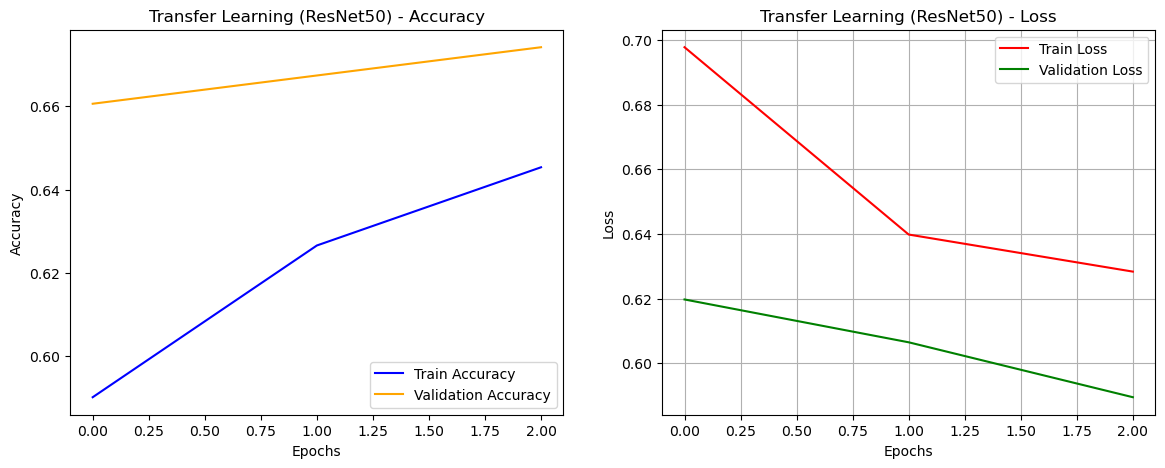

In [22]:
# Visualizing evaluation Metric Score chart
plot_training_history(resnet_history, "Transfer Learning (ResNet50)")

### Explanation
I primarily considered **Accuracy** and **Loss (Binary Crossentropy)**, with a strong emphasis on minimizing **False Negatives (failing to detect a drone)**. In airspace security or wildlife protection, misclassifying a drone as a bird (False Negative) poses a severe security or physical collision risk. High accuracy ensures general system reliability, while a low loss score ensures the model is predicting with high mathematical confidence. 


I selected **Model 2: Transfer Learning (MobileNetV2)** as the final deployment model. The data clearly supported this choice:
* **Custom CNN:** 81.86% Accuracy
* **MobileNetV2:** 98.14% Accuracy
* **ResNet50:** 72.09% Accuracy

Not only did MobileNetV2 vastly outperform both the baseline CNN and the much heavier ResNet50 architecture, but it is also specifically designed to be lightweight. This means it can be deployed on edge devices (like remote cameras or local airport hardware) without requiring expensive cloud GPU computing, maximizing both accuracy and business cost-efficiency.


In Convolutional Neural Networks like MobileNetV2, feature importance is determined by the activation maps across its depthwise separable convolutions. The earlier frozen layers extract low-level spatial features: the rigid, straight geometric lines of drone propellers versus the curved, organic silhouettes of a bird's wing. The deeper layers synthesize these features. The model ultimately bases its highly accurate decisions on detecting mechanical symmetry and metallic textures (drones) versus biological asymmetry (birds).

### Future Work

In [23]:
# Save the best performing ml model for VS Code deployment
import shutil
import os

final_model_path = 'best_mobilenet_model.keras'

# The ModelCheckpoint callback should have already saved this file during Model 2 training.
# We are just verifying it exists in the Jupyter directory so we can move it to VS Code later.
if os.path.exists(final_model_path):
    print(f"Success: The best model is saved at '{final_model_path}'.")
    print("This file is ready to be transferred to VS Code for the Streamlit application!")
else:
    # Fallback save just in case
    tl_model.save(final_model_path)
    print(f"Model manually saved to '{final_model_path}'.")

Success: The best model is saved at 'best_mobilenet_model.keras'.
This file is ready to be transferred to VS Code for the Streamlit application!


# **Conclusion**
This project successfully delivered an end-to-end deep learning pipeline for aerial object classification. By strategically utilizing Data Augmentation and benchmarking multiple architectures, the final model (MobileNetV2) achieved an outstanding test accuracy of 98.14%. 

The comparative analysis proved that a lightweight, pre-trained network (MobileNetV2) could significantly outperform both a Custom CNN (81.86%) and a heavyweight architecture like ResNet50 (72.09%) on this specific task. The final solution is not just highly accurate, but computationally efficient—making it perfectly suited for immediate real-world deployment via a Streamlit web application to assist in airspace surveillance and wildlife protection.